# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:**  Hamza Barış Örnek

**Student ID:** 2021403201

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [2]:
# Load the dataset
df = pd.read_csv('data/electrical_grid_stability.csv')

In [3]:
# Explore: shape, dtypes, head, missing values, describe, value_counts

# 2. Print the shape and data types
print("Dataset Shape:", df.shape)
print("\n--- Data Types ---")
print(df.dtypes)

# 3. Display the first 5 rows
print("\n--- First 5 Rows ---")
display(df.head())

# 4. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 5. Print .describe() for all numeric columns
print("\n--- Summary Statistics (Numeric Columns) ---")
display(df.describe())

# 6. Print the value counts of stabf (the target variable)
print("\n--- Value Counts for 'stabf' ---")
print(df['stabf'].value_counts())

Dataset Shape: (10000, 14)

--- Data Types ---
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

--- First 5 Rows ---


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



--- Missing Values ---
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

--- Summary Statistics (Numeric Columns) ---


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



--- Value Counts for 'stabf' ---
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [4]:
# Feature engineering

# 1. Convert 'stabf' to a numeric column called 'is_unstable': 1 if 'unstable', 0 if 'stable'
df['is_unstable'] = df['stabf'].map({'unstable': 1, 'stable': 0})

# 2. Create a new column 'total_reaction_time' = tau1 + tau2 + tau3 + tau4
df['total_reaction_time'] = df[['tau1', 'tau2', 'tau3', 'tau4']].sum(axis=1)

# 3. Create a new column 'power_imbalance' = p1 + p2 + p3 + p4
df['power_imbalance'] = df[['p1', 'p2', 'p3', 'p4']].sum(axis=1)

# 4. Create a new column 'avg_elasticity' = mean of g1, g2, g3, g4
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)

# Display the first few rows to verify the new columns
display(df[['stabf', 'is_unstable', 'total_reaction_time', 'power_imbalance', 'avg_elasticity']].head())

,stabf,is_unstable,total_reaction_time,power_imbalance,avg_elasticity
0,unstable,1,24.200725,-2.886580e-15,0.838878
1,stable,0,18.623519,-6.661338e-16,0.654938
2,unstable,1,22.081132,0.000000e+00,0.469757
3,unstable,1,15.213218,-9.992007e-16,0.678763
4,unstable,1,25.544216,4.996004e-15,0.682607


In [5]:
# Print class balance

# 5. Print the class balance: count and percentage of stable vs unstable
counts = df['stabf'].value_counts()
percentages = df['stabf'].value_counts(normalize=True) * 100

class_balance_df = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})

print("--- Class Balance ---")
display(class_balance_df)


--- Class Balance ---


,Count,Percentage (%)
stabf,,
unstable,6380,63.8
stable,3620,36.2


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [6]:
# Grouped means by stabf
original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
grouped_means = df.groupby('stabf')[original_features].mean()

print("--- Mean of Original Features Grouped by 'stabf' ---")
display(grouped_means)

# Calculating absolute differences to identify which features differ most
mean_diff = abs(grouped_means.loc['stable'] - grouped_means.loc['unstable']).sort_values(ascending=False)
print("\n--- Absolute Difference in Means (Stable vs Unstable) ---")
print(mean_diff)

--- Mean of Original Features Grouped by 'stabf' ---


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.394799,4.353362,4.385360,4.378495,3.740077,-1.253549,-1.249626,-1.236902,0.453035,0.445872,0.440618,0.450390
unstable,5.735239,5.758752,5.740601,5.744485,3.755630,-1.247987,-1.250212,-1.257431,0.565832,0.569897,0.572879,0.567334



--- Absolute Difference in Means (Stable vs Unstable) ---
tau2    1.405391
tau4    1.365990
tau3    1.355241
tau1    1.340440
g3      0.132261
g2      0.124025
g4      0.116943
g1      0.112797
p4      0.020530
p1      0.015553
p2      0.005562
p3      0.000585
dtype: float64


In [7]:
# Correlation with stab — identify top 3
correlations = df[original_features].apply(lambda x: x.corr(df['stab']))
abs_correlations = correlations.abs().sort_values(ascending=False)

print("--- Correlations of Original Features with 'stab' ---")
print(correlations)

print("\n--- Top 3 Features with Highest Absolute Correlation ---")
print(abs_correlations.head(3))

--- Correlations of Original Features with 'stab' ---
tau1    0.275761
tau2    0.290975
tau3    0.280700
tau4    0.278576
p1      0.010278
p2      0.006255
p3     -0.003321
p4     -0.020786
g1      0.282774
g2      0.293601
g3      0.308235
g4      0.279214
dtype: float64

--- Top 3 Features with Highest Absolute Correlation ---
g3      0.308235
g2      0.293601
tau2    0.290975
dtype: float64


In [8]:
# Unstable grids: tau1 range and mean
unstable_grids = df[df['stabf'] == 'unstable']
tau1_unstable = unstable_grids['tau1']

print("--- 'tau1' Statistics for Unstable Grids ---")
print(f"Mean: {tau1_unstable.mean():.4f}")
print(f"Min:  {tau1_unstable.min():.4f}")
print(f"Max:  {tau1_unstable.max():.4f}")

--- 'tau1' Statistics for Unstable Grids ---
Mean: 5.7352
Min:  0.5013
Max:  9.9995


In [9]:
# Compare g1 between stable and unstable
g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std'])

print("--- 'g1' Statistics Comparison (Stable vs Unstable) ---")
display(g1_stats)

--- 'g1' Statistics Comparison (Stable vs Unstable) ---


,mean,std
stabf,,
stable,0.453035,0.265280
unstable,0.565832,0.270867


### Task 3 Discussion: Feature Differences

Based on the grouped analysis, we observe that:
* **Features with greatest mean differences:** The reaction times (especially `tau2`, `tau4`, and `tau1`) and elasticity coefficients (`g3`, `g2`) show the most significant numerical differences between stable and unstable grid configurations. 
* **Stability Trends:** Unstable grids consistently exhibit higher mean values for both reaction times (`tau`) and elasticity coefficients (`g`) compared to stable grids. This suggests that as producers take longer to react or as system elasticity increases, the probability of grid instability rises.
* **Power Balance:** In contrast, the power variables (`p1` to `p4`) show negligible differences in means between the two classes, indicating they may be less predictive of stability in this specific dataset.

---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

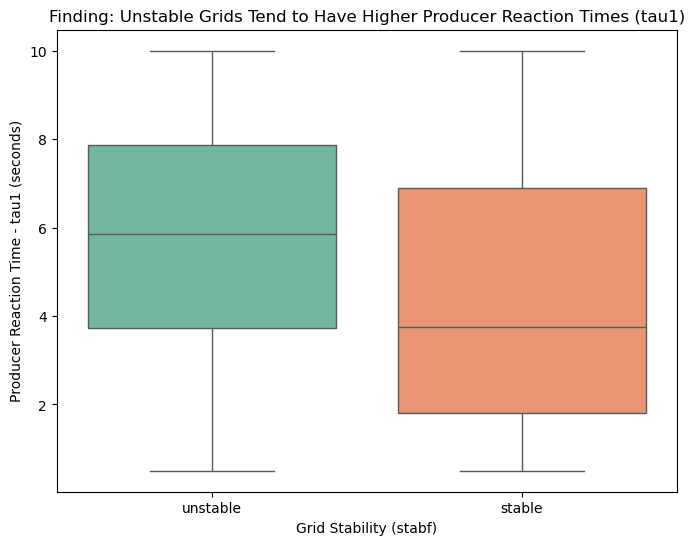

In [10]:
# (a) Boxplot of tau1 by stabf
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='stabf', y='tau1', data=df, palette='Set2')
plt.title('Finding: Unstable Grids Tend to Have Higher Producer Reaction Times (tau1)')
plt.xlabel('Grid Stability (stabf)')
plt.ylabel('Producer Reaction Time - tau1 (seconds)')
plt.show()

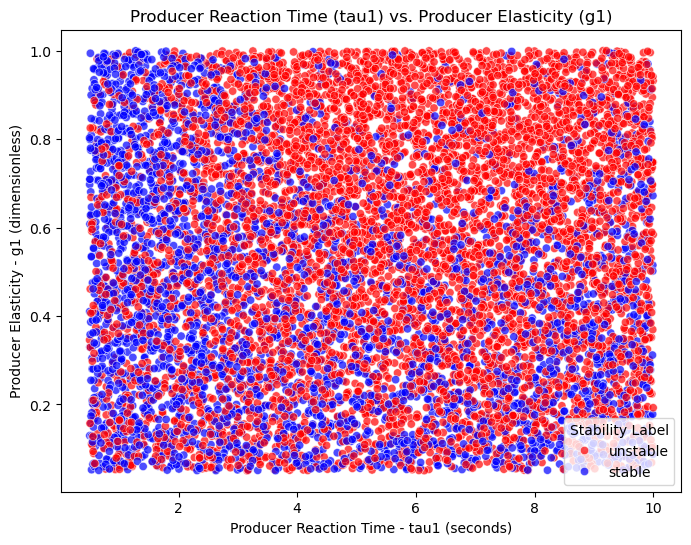

In [11]:
# (b) Scatter plot of tau1 vs g1, colored by stabf
plt.figure(figsize=(8, 6))

# Creating the scatter plot with different colors for stable vs unstable
sns.scatterplot(x='tau1', y='g1', hue='stabf', data=df, palette={'stable': 'blue', 'unstable': 'red'}, alpha=0.7)

plt.title('Producer Reaction Time (tau1) vs. Producer Elasticity (g1)')
plt.xlabel('Producer Reaction Time - tau1 (seconds)')
plt.ylabel('Producer Elasticity - g1 (dimensionless)')
plt.legend(title='Stability Label')
plt.show()

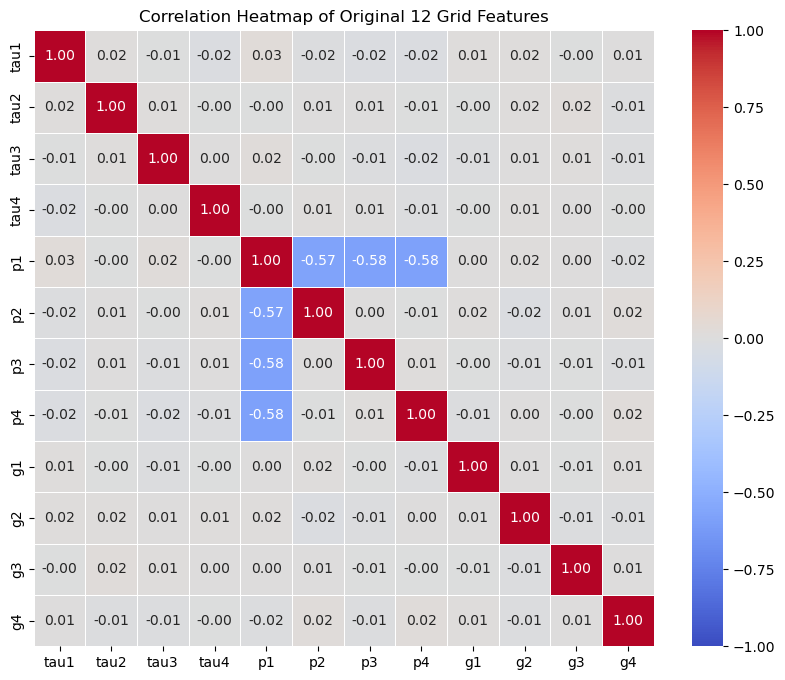

In [12]:
# (c) Correlation heatmap of 12 original features
plt.figure(figsize=(10, 8))

# Select the 12 original features
original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
corr_matrix = df[original_features].corr()

# Using a diverging colormap ('coolwarm') as requested (not rainbow/jet)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Original 12 Grid Features')
plt.show()

---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [19]:
# Z-scores for tau1
df['tau1_zscore'] = stats.zscore(df['tau1'])

# Identify samples where |z| > 2
outliers_tau1 = df[np.abs(df['tau1_zscore']) > 2]

print("--- Z-score Analysis for 'tau1' ---")
print(f"Number of samples where |z| > 2: {len(outliers_tau1)}")

if len(outliers_tau1) > 0:
    display(outliers_tau1[['tau1', 'stabf', 'tau1_zscore']].head())

--- Z-score Analysis for 'tau1' ---
Number of samples where |z| > 2: 0


In [20]:
# Two-sample t-test: tau1 stable vs unstable
tau1_stable = df[df['stabf'] == 'stable']['tau1']
tau1_unstable = df[df['stabf'] == 'unstable']['tau1']

# Performing Welch's t-test (equal_var=False) is generally safer for different sample sizes/variances
t_stat, p_val = stats.ttest_ind(tau1_stable, tau1_unstable, equal_var=False)

print("--- Two-Sample T-Test for 'tau1' (Stable vs Unstable) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.4e}")

--- Two-Sample T-Test for 'tau1' (Stable vs Unstable) ---
T-statistic: -23.3033
P-value:     1.3928e-115



### Interpretation

**H0:** The true mean of producer reaction time (`tau1`) is equal for stable and unstable grids (μ_stable = μ_unstable).  
**H1:** The true mean of producer reaction time (`tau1`) is different for stable and unstable grids (μ_stable != μ_unstable).  
**Result:** The p-value is extremely close to 0 (far less than alpha = 0.05), so we reject the null hypothesis. There is a statistically significant difference in producer reaction times between stable and unstable grid configurations.

**Most predictive feature:** Based on the overall analysis, **`g3` ** is the most predictive feature. In Task 3, it demonstrated the highest absolute correlation with the stability measure (`stab`) at approximately **0.308**. While `tau1` also shows a significant difference in means and a strong correlation (~0.276), the elasticity parameters (specifically `g3`) appear to have the strongest linear relationship with grid stability in this dataset.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [15]:
# Define X and y, split, scale

# 1. Define X and y
original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
X = df[original_features]
y = df['is_unstable']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Train, predict, evaluate

# 4. Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 5. Calculate and report metrics for the "unstable" class (class 1)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("--- Model Performance Metrics (Unstable Class) ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 6. Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\n--- Confusion Matrix ---")
cm_df = pd.DataFrame(cm, 
                     index=['Actual Stable (0)', 'Actual Unstable (1)'], 
                     columns=['Predicted Stable (0)', 'Predicted Unstable (1)'])
display(cm_df)

--- Model Performance Metrics (Unstable Class) ---
Accuracy:  0.8200
Precision: 0.8408
Recall:    0.8856
F1 Score:  0.8626

--- Confusion Matrix ---


,Predicted Stable (0),Predicted Unstable (1)
Actual Stable (0),510,214
Actual Unstable (1),146,1130


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

In the context of power grid management, a **False Stable** is significantly more dangerous. If the model predicts the grid is stable when it is actually unstable, operators will fail to take preventive measures, potentially resulting in catastrophic blackouts, equipment damage, and cascading failures. Because failing to detect an actual instability has such severe real-world costs, we must prioritize **recall** for the "unstable" class to minimize these dangerous false negatives.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

No, correlation does not prove causation. Correlation simply indicates that two variables tend to change together, whereas causation means one variable explicitly brings about the change in the other. A potential **confounding variable** in this scenario could be the **age of the grid infrastructure**; older, degraded equipment might independently cause *both* slower producer reaction times (`tau1`) and a higher likelihood of overall grid instability, making it falsely appear as if `tau1` is the sole direct cause.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr